In [128]:
from numbers import Number

import accelforge as af

In [129]:
### GPT 175B (target model)

In [136]:
ARCH = "designs/arch.yaml" # tpuv4 
VALIDATOR = "designs/gpt3_175b.yaml" #gpt3 
DRAFT = "designs/gpt3_6.7b.yaml" # 6.7 b model

In [137]:
from pathlib import Path

# examples_dir = Path("../../examples")

# < DOC_INCLUDE_MARKER > make_spec
import accelforge as af

# Set the number of parallel threads that the mapper can use. If you are running out of
# memory, you may decrease this number. By default the number of threads is set to the
# number of cores on your machine.
import os
# af.set_n_parallel_jobs(os.cpu_count(), print_message=True)

# Initialize the spec and show the workload.
BATCH_SIZE = 1
N_TOKENS = 8192
FUSE = False
spec = af.Spec.from_yaml(
    ARCH,
    DRAFT,
    jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS, "N_NEW_TOKENS": 1},
)
# Fusion happens when tensors bypass the outermost Memory object, so, to disable fusion,
# force all tensors to be in the outermost memory.
if not FUSE:
    for node in spec.arch.nodes:
        if isinstance(node, af.arch.Memory):
            print(f'Keeping all tensors in {node.name}')
            node.tensors.keep = "All"
            break

Keeping all tensors in MainMemory


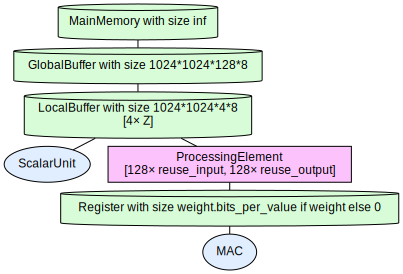

In [138]:
spec.arch

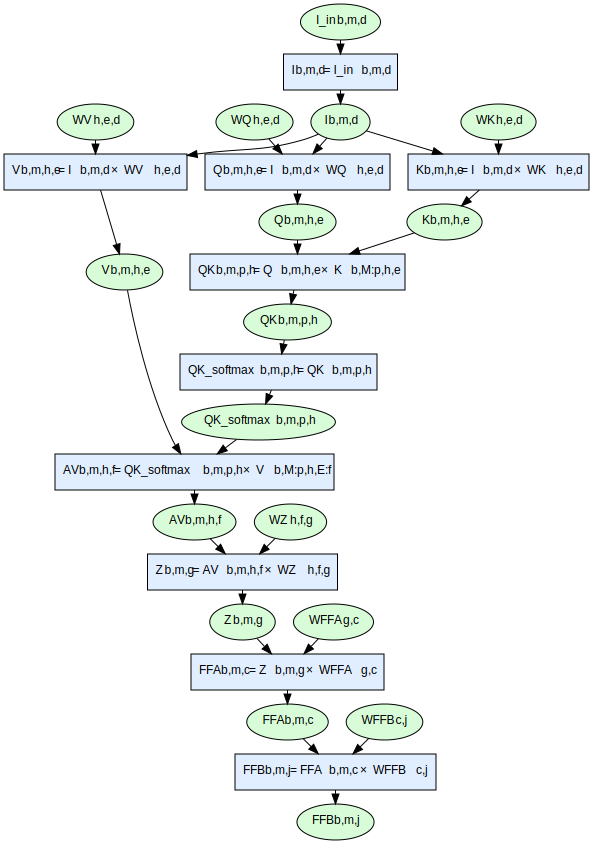

In [139]:
spec.workload

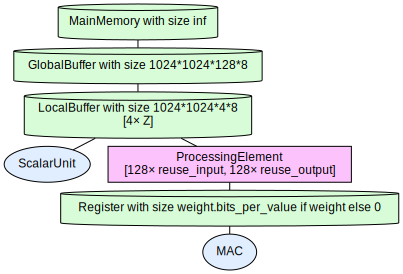

In [140]:
spec.arch

In [142]:
result = spec.map_workload_to_arch()
result





Getting energy, latency, and leak power for components running :   0%|          | 0/10 [00:00<?, ?it/s]



Getting energy, latency, and leak power for components running I:   0%|          | 0/10 [00:00<?, ?it/s]



Getting energy, latency, and leak power for components running V:   0%|          | 0/10 [00:00<?, ?it/s]



Getting energy, latency, and leak power for components running K:   0%|          | 0/10 [00:00<?, ?it/s]



Getting energy, latency, and leak power for components running Q:   0%|          | 0/10 [00:00<?, ?it/s]



Getting energy, latency, and leak power for components running Q:  40%|████      | 4/10 [00:00<00:00, 35.58it/s]



Getting energy, latency, and leak power for components running QK:  40%|████      | 4/10 [00:00<00:00, 35.58it/s]



Getting energy, latency, and leak power for components running QK_softmax:  40%|████      | 4/10 [00:00<00:00, 35.58it/s]



Getting energy, latency, and leak power for components running AV:  40%|████      | 4/10 [00:00<00:

KeyError: 'AV'